In [1]:

# imports
import os
import sys
import types
import json
import base64

# figure size/format
fig_width = 8
fig_height = 5
fig_format = 'png'
fig_dpi = 96
interactivity = ''
is_shiny = False
is_dashboard = False
plotly_connected = True

# matplotlib defaults / format
try:
  import matplotlib.pyplot as plt
  plt.rcParams['figure.figsize'] = (fig_width, fig_height)
  plt.rcParams['figure.dpi'] = fig_dpi
  plt.rcParams['savefig.dpi'] = "figure"

  # IPython 7.14 deprecated set_matplotlib_formats from IPython
  try:
    from matplotlib_inline.backend_inline import set_matplotlib_formats
  except ImportError:
    # Fall back to deprecated location for older IPython versions
    from IPython.display import set_matplotlib_formats
    
  set_matplotlib_formats(fig_format)
except Exception:
  pass

# plotly use connected mode
try:
  import plotly.io as pio
  if plotly_connected:
    pio.renderers.default = "notebook_connected"
  else:
    pio.renderers.default = "notebook"
  for template in pio.templates.keys():
    pio.templates[template].layout.margin = dict(t=30,r=0,b=0,l=0)
except Exception:
  pass

# disable itables paging for dashboards
if is_dashboard:
  try:
    from itables import options
    options.dom = 'fiBrtlp'
    options.maxBytes = 1024 * 1024
    options.language = dict(info = "Showing _TOTAL_ entries")
    options.classes = "display nowrap compact"
    options.paging = False
    options.searching = True
    options.ordering = True
    options.info = True
    options.lengthChange = False
    options.autoWidth = False
    options.responsive = True
    options.keys = True
    options.buttons = []
  except Exception:
    pass
  
  try:
    import altair as alt
    # By default, dashboards will have container sized
    # vega visualizations which allows them to flow reasonably
    theme_sentinel = '_quarto-dashboard-internal'
    def make_theme(name):
        nonTheme = alt.themes._plugins[name]    
        def patch_theme(*args, **kwargs):
            existingTheme = nonTheme()
            if 'height' not in existingTheme:
              existingTheme['height'] = 'container'
            if 'width' not in existingTheme:
              existingTheme['width'] = 'container'

            if 'config' not in existingTheme:
              existingTheme['config'] = dict()
            
            # Configure the default font sizes
            title_font_size = 15
            header_font_size = 13
            axis_font_size = 12
            legend_font_size = 12
            mark_font_size = 12
            tooltip = False

            config = existingTheme['config']

            # The Axis
            if 'axis' not in config:
              config['axis'] = dict()
            axis = config['axis']
            if 'labelFontSize' not in axis:
              axis['labelFontSize'] = axis_font_size
            if 'titleFontSize' not in axis:
              axis['titleFontSize'] = axis_font_size  

            # The legend
            if 'legend' not in config:
              config['legend'] = dict()
            legend = config['legend']
            if 'labelFontSize' not in legend:
              legend['labelFontSize'] = legend_font_size
            if 'titleFontSize' not in legend:
              legend['titleFontSize'] = legend_font_size  

            # The header
            if 'header' not in config:
              config['header'] = dict()
            header = config['header']
            if 'labelFontSize' not in header:
              header['labelFontSize'] = header_font_size
            if 'titleFontSize' not in header:
              header['titleFontSize'] = header_font_size    

            # Title
            if 'title' not in config:
              config['title'] = dict()
            title = config['title']
            if 'fontSize' not in title:
              title['fontSize'] = title_font_size

            # Marks
            if 'mark' not in config:
              config['mark'] = dict()
            mark = config['mark']
            if 'fontSize' not in mark:
              mark['fontSize'] = mark_font_size

            # Mark tooltips
            if tooltip and 'tooltip' not in mark:
              mark['tooltip'] = dict(content="encoding")

            return existingTheme
            
        return patch_theme

    # We can only do this once per session
    if theme_sentinel not in alt.themes.names():
      for name in alt.themes.names():
        alt.themes.register(name, make_theme(name))
      
      # register a sentinel theme so we only do this once
      alt.themes.register(theme_sentinel, make_theme('default'))
      alt.themes.enable('default')

  except Exception:
    pass

# enable pandas latex repr when targeting pdfs
try:
  import pandas as pd
  if fig_format == 'pdf':
    pd.set_option('display.latex.repr', True)
except Exception:
  pass

# interactivity
if interactivity:
  from IPython.core.interactiveshell import InteractiveShell
  InteractiveShell.ast_node_interactivity = interactivity

# NOTE: the kernel_deps code is repeated in the cleanup.py file
# (we can't easily share this code b/c of the way it is run).
# If you edit this code also edit the same code in cleanup.py!

# output kernel dependencies
kernel_deps = dict()
for module in list(sys.modules.values()):
  # Some modules play games with sys.modules (e.g. email/__init__.py
  # in the standard library), and occasionally this can cause strange
  # failures in getattr.  Just ignore anything that's not an ordinary
  # module.
  if not isinstance(module, types.ModuleType):
    continue
  path = getattr(module, "__file__", None)
  if not path:
    continue
  if path.endswith(".pyc") or path.endswith(".pyo"):
    path = path[:-1]
  if not os.path.exists(path):
    continue
  kernel_deps[path] = os.stat(path).st_mtime
print(json.dumps(kernel_deps))

# set run_path if requested
run_path = 'RjpcTWVudWxpcyBidWt1IGRlbmdhbiBRdWFydG9caWdjc2UtcGh5c2ljcy1yZXZpc2lvblxjaGFwdGVycw=='
if run_path:
  # hex-decode the path
  run_path = base64.b64decode(run_path.encode("utf-8")).decode("utf-8")
  os.chdir(run_path)

# reset state
%reset

# shiny
# Checking for shiny by using False directly because we're after the %reset. We don't want
# to set a variable that stays in global scope.
if False:
  try:
    import htmltools as _htmltools
    import ast as _ast

    _htmltools.html_dependency_render_mode = "json"

    # This decorator will be added to all function definitions
    def _display_if_has_repr_html(x):
      try:
        # IPython 7.14 preferred import
        from IPython.display import display, HTML
      except:
        from IPython.core.display import display, HTML

      if hasattr(x, '_repr_html_'):
        display(HTML(x._repr_html_()))
      return x

    # ideally we would undo the call to ast_transformers.append
    # at the end of this block whenver an error occurs, we do 
    # this for now as it will only be a problem if the user 
    # switches from shiny to not-shiny mode (and even then likely
    # won't matter)
    import builtins
    builtins._display_if_has_repr_html = _display_if_has_repr_html

    class _FunctionDefReprHtml(_ast.NodeTransformer):
      def visit_FunctionDef(self, node):
        node.decorator_list.insert(
          0,
          _ast.Name(id="_display_if_has_repr_html", ctx=_ast.Load())
        )
        return node

      def visit_AsyncFunctionDef(self, node):
        node.decorator_list.insert(
          0,
          _ast.Name(id="_display_if_has_repr_html", ctx=_ast.Load())
        )
        return node

    ip = get_ipython()
    ip.ast_transformers.append(_FunctionDefReprHtml())

  except:
    pass

def ojs_define(**kwargs):
  import json
  try:
    # IPython 7.14 preferred import
    from IPython.display import display, HTML
  except:
    from IPython.core.display import display, HTML

  # do some minor magic for convenience when handling pandas
  # dataframes
  def convert(v):
    try:
      import pandas as pd
    except ModuleNotFoundError: # don't do the magic when pandas is not available
      return v
    if type(v) == pd.Series:
      v = pd.DataFrame(v)
    if type(v) == pd.DataFrame:
      j = json.loads(v.T.to_json(orient='split'))
      return dict((k,v) for (k,v) in zip(j["index"], j["data"]))
    else:
      return v

  v = dict(contents=list(dict(name=key, value=convert(value)) for (key, value) in kwargs.items()))
  display(HTML('<script type="ojs-define">' + json.dumps(v) + '</script>'), metadata=dict(ojs_define = True))
globals()["ojs_define"] = ojs_define
globals()["__spec__"] = None

{"C:\\Users\\User\\AppData\\Local\\Programs\\Python\\Python312\\Lib\\importlib\\_bootstrap.py": 1744091812.0, "C:\\Users\\User\\AppData\\Local\\Programs\\Python\\Python312\\Lib\\importlib\\_bootstrap_external.py": 1744091812.0, "C:\\Users\\User\\AppData\\Local\\Programs\\Python\\Python312\\Lib\\zipimport.py": 1744091814.0, "C:\\Users\\User\\AppData\\Local\\Programs\\Python\\Python312\\Lib\\codecs.py": 1744091812.0, "C:\\Users\\User\\AppData\\Local\\Programs\\Python\\Python312\\Lib\\encodings\\aliases.py": 1744091812.0, "C:\\Users\\User\\AppData\\Local\\Programs\\Python\\Python312\\Lib\\encodings\\__init__.py": 1744091812.0, "C:\\Users\\User\\AppData\\Local\\Programs\\Python\\Python312\\Lib\\encodings\\utf_8.py": 1744091812.0, "C:\\Users\\User\\AppData\\Local\\Programs\\Python\\Python312\\Lib\\encodings\\cp1252.py": 1744091812.0, "C:\\Users\\User\\AppData\\Local\\Programs\\Python\\Python312\\Lib\\abc.py": 1744091812.0, "C:\\Users\\User\\AppData\\Local\\Programs\\Python\\Python312\\Lib\\

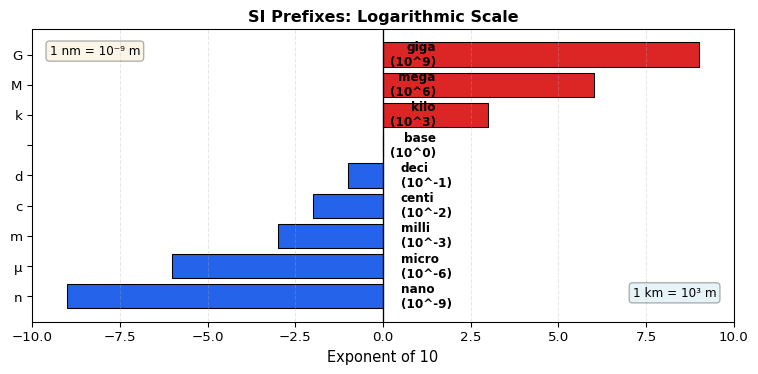

In [2]:
#| label: fig-si-prefixes
#| fig-cap: SI prefixes on a logarithmic scale showing multiples and submultiples
#| fig-align: center
#| warning: false

import numpy as np
import matplotlib.pyplot as plt

# SI prefixes data
prefixes = ['n', 'μ', 'm', 'c', 'd', '', 'k', 'M', 'G']
factors = [-9, -6, -3, -2, -1, 0, 3, 6, 9]
names = ['nano', 'micro', 'milli', 'centi', 'deci', 'base', 'kilo', 'mega', 'giga']
colors = ['#2563eb' if f < 0 else '#059669' if f == 0 else '#dc2626' for f in factors]

fig, ax = plt.subplots(figsize=(8, 4))
ax.barh(prefixes, factors, color=colors, edgecolor='black', linewidth=0.8)

# Add labels
for i, (p, f, n) in enumerate(zip(prefixes, factors, names)):
    label = f'{n}\n(10^{f})' if f != 0 else f'{n}\n(10^0)'
    ax.text(0.5 if f < 0 else 1.5, i, label, 
            va='center', ha='left' if f < 0 else 'right',
            fontsize=9, fontweight='bold')

ax.set_xlabel('Exponent of 10', fontsize=11)
ax.set_title('SI Prefixes: Logarithmic Scale', fontsize=12, fontweight='bold')
ax.set_xlim(-10, 10)
ax.grid(axis='x', alpha=0.3, linestyle='--')
ax.axvline(x=0, color='black', linewidth=1)

# Add example annotations
ax.text(-9.5, 8, '1 nm = 10⁻⁹ m', fontsize=9, bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.3))
ax.text(9.5, 0, '1 km = 10³ m', fontsize=9, bbox=dict(boxstyle='round', facecolor='lightblue', alpha=0.3), ha='right')

plt.tight_layout()
plt.show()

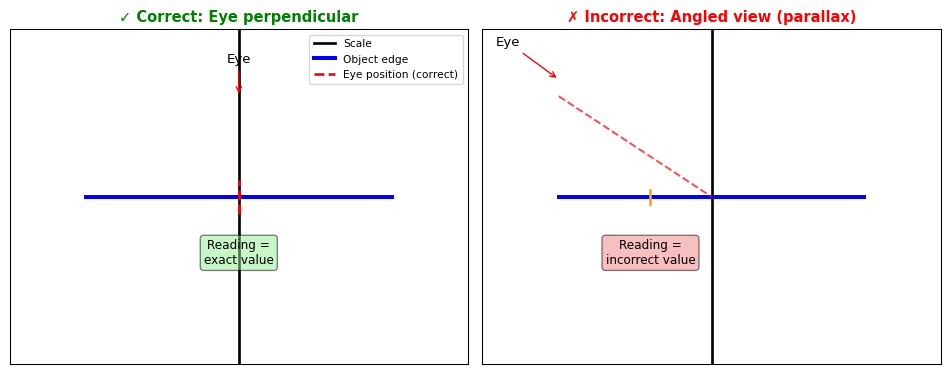

In [3]:
#| label: fig-parallax-error
#| fig-cap: 'Parallax error: correct vs incorrect eye position when reading a scale'
#| fig-align: center
#| warning: false

import matplotlib.pyplot as plt
import numpy as np

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4))

# Correct viewing (perpendicular)
ax1.axvline(x=0, ymin=0, ymax=1, color='black', linewidth=2, label='Scale')
ax1.plot([-2, 2], [0.5, 0.5], 'b-', linewidth=3, label='Object edge')
ax1.plot([0, 0], [0.45, 0.55], 'r--', linewidth=2, label="Eye position (correct)")
ax1.annotate('Eye', xy=(0, 0.8), xytext=(0, 0.9),
             arrowprops=dict(arrowstyle='->', color='red'),
             ha='center', fontsize=10)
ax1.text(0, 0.3, 'Reading =\nexact value', ha='center', fontsize=9, 
         bbox=dict(boxstyle='round', facecolor='lightgreen', alpha=0.5))
ax1.set_xlim(-3, 3)
ax1.set_ylim(0, 1)
ax1.set_title('✓ Correct: Eye perpendicular', fontsize=11, fontweight='bold', color='green')
ax1.set_xticks([])
ax1.set_yticks([])
ax1.grid(axis='y', alpha=0.2)
ax1.legend(fontsize=8)

# Incorrect viewing (angled - parallax)
ax2.axvline(x=0, ymin=0, ymax=1, color='black', linewidth=2)
ax2.plot([-2, 2], [0.5, 0.5], 'b-', linewidth=3)
ax2.plot([-2, 0], [0.8, 0.5], 'r--', linewidth=1.5, alpha=0.7)  # Line of sight
ax2.annotate('Eye', xy=(-2, 0.85), xytext=(-2.5, 0.95),
             arrowprops=dict(arrowstyle='->', color='red'),
             ha='right', fontsize=10)
ax2.axvline(x=-0.8, ymin=0.48, ymax=0.52, color='orange', linewidth=2, 
            label='Apparent position')
ax2.text(-0.8, 0.3, 'Reading =\nincorrect value', ha='center', fontsize=9,
         bbox=dict(boxstyle='round', facecolor='lightcoral', alpha=0.5))
ax2.set_xlim(-3, 3)
ax2.set_ylim(0, 1)
ax2.set_title('✗ Incorrect: Angled view (parallax)', fontsize=11, fontweight='bold', color='red')
ax2.set_xticks([])
ax2.set_yticks([])
ax2.grid(axis='y', alpha=0.2)

plt.tight_layout()
plt.show()

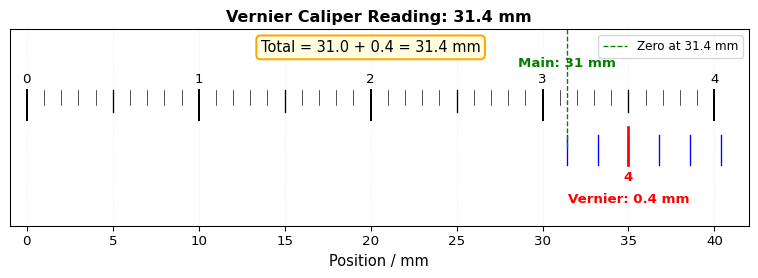

In [4]:
#| label: fig-vernier-reading
#| fig-cap: 'Reading vernier calipers: main scale + vernier scale alignment'
#| fig-align: center
#| warning: false

import matplotlib.pyplot as plt
import numpy as np

fig, ax = plt.subplots(figsize=(8, 3))

# Main scale (0 to 4 cm, marked every 1 mm)
main_ticks = np.arange(0, 41, 1)  # 0 to 40 mm
for i, tick in enumerate(main_ticks):
    if tick % 10 == 0:  # cm marks
        ax.plot([tick, tick], [0.6, 1.0], 'k-', linewidth=1.5)
        ax.text(tick, 1.1, f'{tick//10}', ha='center', fontsize=10)
    elif tick % 5 == 0:  # half-cm marks
        ax.plot([tick, tick], [0.7, 1.0], 'k-', linewidth=1)
    else:  # mm marks
        ax.plot([tick, tick], [0.8, 1.0], 'k-', linewidth=0.5)

# Vernier scale (10 divisions over 9 mm, zero at 31.4 mm)
vernier_zero = 31.4
vernier_divisions = np.linspace(vernier_zero, vernier_zero + 9, 11)
for i, pos in enumerate(vernier_divisions):
    if i % 2 == 0:  # Mark every other division for clarity
        ax.plot([pos, pos], [0.0, 0.4], 'b-', linewidth=1)
        if i == 4:  # The coinciding mark (vernier 4 aligns with main 35)
            ax.plot([pos, pos], [0.0, 0.5], 'r-', linewidth=2)
            ax.text(pos, -0.2, '4', ha='center', color='red', fontweight='bold')

# Highlight the reading
ax.axvline(x=vernier_zero, ymin=0.4, ymax=1.0, color='green', linestyle='--', 
           linewidth=1, label=f'Zero at {vernier_zero} mm')
ax.text(vernier_zero, 1.3, f'Main: {int(vernier_zero)} mm', ha='center', 
        fontsize=10, fontweight='bold', color='green')
ax.text(35, -0.5, f'Vernier: 0.4 mm', ha='center', 
        fontsize=10, fontweight='bold', color='red')

# Final result box
ax.text(20, 1.5, 'Total = 31.0 + 0.4 = 31.4 mm', ha='center', fontsize=11,
        bbox=dict(boxstyle='round', facecolor='lightyellow', edgecolor='orange', linewidth=1.5))

ax.set_xlim(-1, 42)
ax.set_ylim(-0.8, 1.8)
ax.set_xlabel('Position / mm', fontsize=11)
ax.set_title('Vernier Caliper Reading: 31.4 mm', fontsize=12, fontweight='bold')
ax.grid(axis='x', alpha=0.2, linestyle=':')
ax.set_yticks([])
ax.legend(fontsize=9, loc='upper right')

plt.tight_layout()
plt.show()

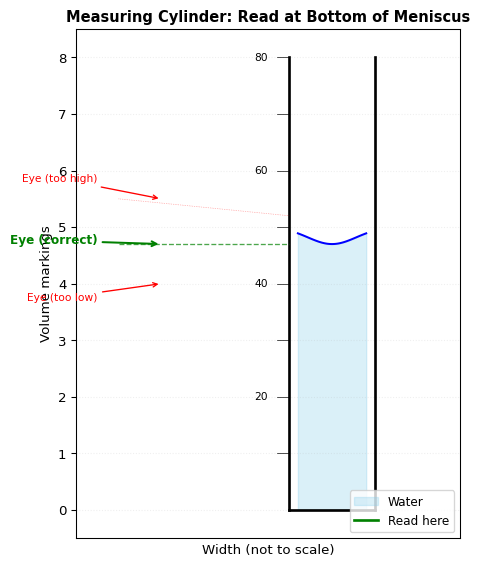

In [5]:
#| label: fig-meniscus-reading
#| fig-cap: 'Reading a measuring cylinder: bottom of the meniscus at eye level'
#| fig-align: center
#| warning: false

import matplotlib.pyplot as plt
import numpy as np

fig, ax = plt.subplots(figsize=(5, 6))

# Draw cylinder
cylinder_width = 2
cylinder_height = 8
ax.plot([-cylinder_width/2, -cylinder_width/2], [0, cylinder_height], 'k-', linewidth=2)
ax.plot([cylinder_width/2, cylinder_width/2], [0, cylinder_height], 'k-', linewidth=2)
ax.plot([-cylinder_width/2, cylinder_width/2], [0, 0], 'k-', linewidth=2)

# Draw water with concave meniscus
water_level = 5
x = np.linspace(-cylinder_width/2 + 0.2, cylinder_width/2 - 0.2, 100)
meniscus = water_level - 0.3 * np.exp(-((x)/0.8)**2)  # Concave curve
ax.fill_between(x, 0, meniscus, alpha=0.3, color='skyblue', label='Water')
ax.plot(x, meniscus, 'b-', linewidth=1.5)

# Markings on cylinder
for i in range(1, 9):
    y_pos = i
    ax.plot([-cylinder_width/2 - 0.3, -cylinder_width/2], [y_pos, y_pos], 'k-', linewidth=0.5)
    if i % 2 == 0:
        ax.text(-cylinder_width/2 - 0.5, y_pos, f'{i*10}', ha='right', va='center', fontsize=8)

# Eye positions
# Correct: at bottom of meniscus
ax.annotate('Eye (correct)', xy=(-4, water_level - 0.3), xytext=(-5.5, water_level - 0.3),
            arrowprops=dict(arrowstyle='->', color='green', linewidth=1.5),
            ha='right', fontsize=9, color='green', fontweight='bold')
ax.plot([-5, -cylinder_width/2], [water_level - 0.3, water_level - 0.3], 
        'g--', linewidth=1, alpha=0.7)
ax.plot([water_level - 0.3, water_level - 0.3], [-0.2, water_level - 0.1], 
        'g-', linewidth=2, label='Read here')

# Incorrect: above meniscus
ax.annotate('Eye (too high)', xy=(-4, water_level + 0.5), xytext=(-5.5, water_level + 0.8),
            arrowprops=dict(arrowstyle='->', color='red', linewidth=1),
            ha='right', fontsize=8, color='red')
ax.plot([-5, -cylinder_width/2], [water_level + 0.5, water_level + 0.2], 
        'r:', linewidth=0.5, alpha=0.5)

# Incorrect: below meniscus  
ax.annotate('Eye (too low)', xy=(-4, water_level - 1.0), xytext=(-5.5, water_level - 1.3),
            arrowprops=dict(arrowstyle='->', color='red', linewidth=1),
            ha='right', fontsize=8, color='red')

ax.set_xlim(-6, 3)
ax.set_ylim(-0.5, cylinder_height + 0.5)
ax.set_xlabel('Width (not to scale)', fontsize=10)
ax.set_ylabel('Volume markings', fontsize=10)
ax.set_title('Measuring Cylinder: Read at Bottom of Meniscus', fontsize=11, fontweight='bold')
ax.grid(axis='y', alpha=0.2, linestyle=':')
ax.legend(fontsize=9, loc='lower right')
ax.set_xticks([])

plt.tight_layout()
plt.show()

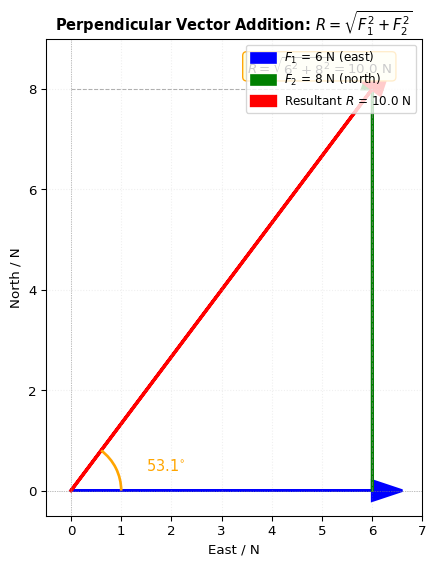

In [6]:
#| label: fig-vector-addition
#| fig-cap: 'Vector addition: resultant of two perpendicular forces using Pythagoras'' theorem'
#| fig-align: center
#| warning: false

import matplotlib.pyplot as plt
import numpy as np
import matplotlib.patches as mpatches

# Define two perpendicular vectors
F1 = 6  # N, along x-axis (east)
F2 = 8  # N, along y-axis (north)

# Calculate resultant
R = np.sqrt(F1**2 + F2**2)
theta = np.degrees(np.arctan2(F2, F1))

# Create figure
fig, ax = plt.subplots(figsize=(6, 6))

# Draw coordinate axes
ax.axhline(y=0, color='gray', linewidth=0.5, linestyle=':')
ax.axvline(x=0, color='gray', linewidth=0.5, linestyle=':')

# Draw F1 (horizontal, blue)
ax.arrow(0, 0, F1, 0, head_width=0.4, head_length=0.6, 
         fc='blue', ec='blue', linewidth=2, label=f'$F_1$ = {F1} N (east)')

# Draw F2 from tip of F1 (vertical, green) - tip-to-tail method
ax.arrow(F1, 0, 0, F2, head_width=0.4, head_length=0.6, 
         fc='green', ec='green', linewidth=2, label=f'$F_2$ = {F2} N (north)')

# Draw resultant R (red, from origin to final tip)
ax.arrow(0, 0, F1, F2, head_width=0.4, head_length=0.6, 
         fc='red', ec='red', linewidth=2.5, label=f'Resultant $R$ = {R:.1f} N')

# Draw dashed lines to complete rectangle (parallelogram method)
ax.plot([F1, F1], [0, F2], 'gray', linestyle='--', linewidth=0.8, alpha=0.6)
ax.plot([0, F1], [F2, F2], 'gray', linestyle='--', linewidth=0.8, alpha=0.6)

# Draw angle arc
angle_arc = mpatches.Arc((0, 0), width=2.0, height=2.0, angle=0, 
                         theta1=0, theta2=theta, color='orange', linewidth=2)
ax.add_patch(angle_arc)
ax.text(1.5, 0.4, f'${theta:.1f}^{{\\circ}}$', fontsize=11, color='orange', fontweight='bold')

# Labels and styling
ax.set_xlabel('East / N', fontsize=10)
ax.set_ylabel('North / N', fontsize=10)
ax.set_title('Perpendicular Vector Addition: $R = \\sqrt{F_1^2 + F_2^2}$', 
             fontsize=11, fontweight='bold')
ax.legend(loc='upper right', fontsize=9)
ax.grid(True, alpha=0.2, linestyle=':')
ax.set_aspect('equal')
ax.set_xlim(-0.5, F1 + 1)
ax.set_ylim(-0.5, F2 + 1)

# Add calculation box
ax.text(F1/2 + 0.5, F2 + 0.3, 
        f'$R = \\sqrt{{{F1}^2 + {F2}^2}} = {R:.1f}\\ \\text{{N}}$', 
        fontsize=10, bbox=dict(boxstyle='round', facecolor='lightyellow', edgecolor='orange'))

plt.tight_layout()
plt.show()

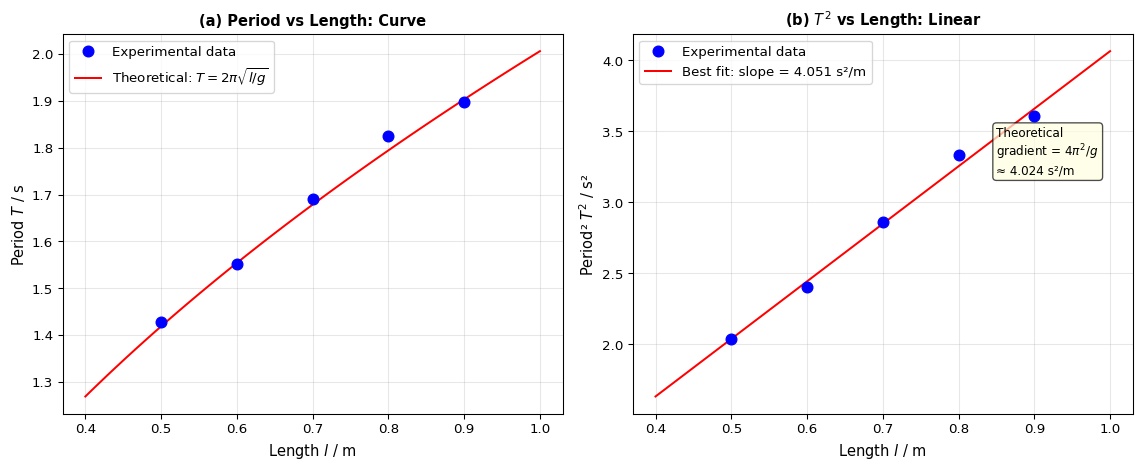

In [7]:
#| label: fig-pendulum-analysis
#| fig-cap: 'Pendulum analysis: T vs l (curve) and T² vs l (linear) graphs'
#| fig-align: center
#| warning: false

import numpy as np
import matplotlib.pyplot as plt

# Simulated experimental data (with small random error)
np.random.seed(42)
l_values = np.array([0.500, 0.600, 0.700, 0.800, 0.900])
g = 9.81
T_theoretical = 2 * np.pi * np.sqrt(l_values / g)
T_measured = T_theoretical + np.random.normal(0, 0.02, size=len(l_values))  # Add small error

# Create subplots
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

# Graph 1: T vs l (non-linear curve)
ax1.plot(l_values, T_measured, 'bo', markersize=8, label='Experimental data', zorder=5)
l_smooth = np.linspace(0.4, 1.0, 100)
T_smooth = 2 * np.pi * np.sqrt(l_smooth / g)
ax1.plot(l_smooth, T_smooth, 'r-', linewidth=1.5, label='Theoretical: $T = 2\\pi\\sqrt{l/g}$')
ax1.set_xlabel('Length $l$ / m', fontsize=11)
ax1.set_ylabel('Period $T$ / s', fontsize=11)
ax1.set_title('(a) Period vs Length: Curve', fontsize=11, fontweight='bold')
ax1.grid(True, alpha=0.3)
ax1.legend(fontsize=10)

# Graph 2: T² vs l (linear relationship)
T2_measured = T_measured**2
T2_theoretical = T_theoretical**2

ax2.plot(l_values, T2_measured, 'bo', markersize=8, label='Experimental data', zorder=5)
# Linear fit
coeffs = np.polyfit(l_values, T2_measured, 1)
fit_line = np.poly1d(coeffs)
ax2.plot(l_smooth, fit_line(l_smooth), 'r-', linewidth=1.5, 
         label=f'Best fit: slope = {coeffs[0]:.3f} s²/m')
ax2.set_xlabel('Length $l$ / m', fontsize=11)
ax2.set_ylabel('Period² $T^2$ / s²', fontsize=11)
ax2.set_title('(b) $T^2$ vs Length: Linear', fontsize=11, fontweight='bold')
ax2.grid(True, alpha=0.3)
ax2.legend(fontsize=10)

# Add theoretical gradient annotation
theoretical_gradient = 4 * np.pi**2 / g
ax2.text(0.85, 3.2, f'Theoretical\ngradient = $4\\pi^2/g$\n≈ {theoretical_gradient:.3f} s²/m', 
         fontsize=9, bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.7))

plt.tight_layout()
plt.show()